<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Probabilistic-Models-%5BWeek-06%5D/Probabilistic_Models_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [1]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 14.5 MB/s eta 0:00:00


In [2]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [3]:
# Group A: all Month-to-month contract rows
# Group B: all Two year contract rows
# Group A_small: 40 random rows from Group A, random_state=42
group_A       = df[df["Contract"].str.contains("Month-to-month")]
group_B       = df[df["Contract"].str.contains("Two year")]
group_A_small = group_A.sample(n=40, random_state=42)
# raise NotImplementedError("Extract group_A, group_B, group_A_small")

k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")


Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [4]:
alpha_prior, beta_prior = 2, 8   # Beta(2, 8) prior — do not change

# YOUR CODE HERE — for each group compute:
#   mle     = k / n
#   map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
#   pull    = |map_est - mle|  (how far prior pulls MAP from MLE)

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n   # YOUR CODE HERE
    map_est = (alpha_prior + k -1) / (alpha_prior + beta_prior + n -2)   # YOUR CODE HERE
    pull    = np.absolute(map_est - mle )  # YOUR CODE HERE
    # raise NotImplementedError("Compute MLE, MAP, and pull for each group")
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


The MLE is observed churn rate directly on data. MAP is estimated churn with prior beleif of Beta(2,4). MAP-MLE shows how much piror had the effect on estimate.

Prior expected churn around < 30%.

For Group A and Group B with large datapoints, the churn rate is similar on 42% and 28%. Whereas, in the smaller group a, the estimate churn rate is pulled down from 37.5% to 33.33% towards he prior < 30% beleif. Having a noticable effect of 4.17% towards the prior.  

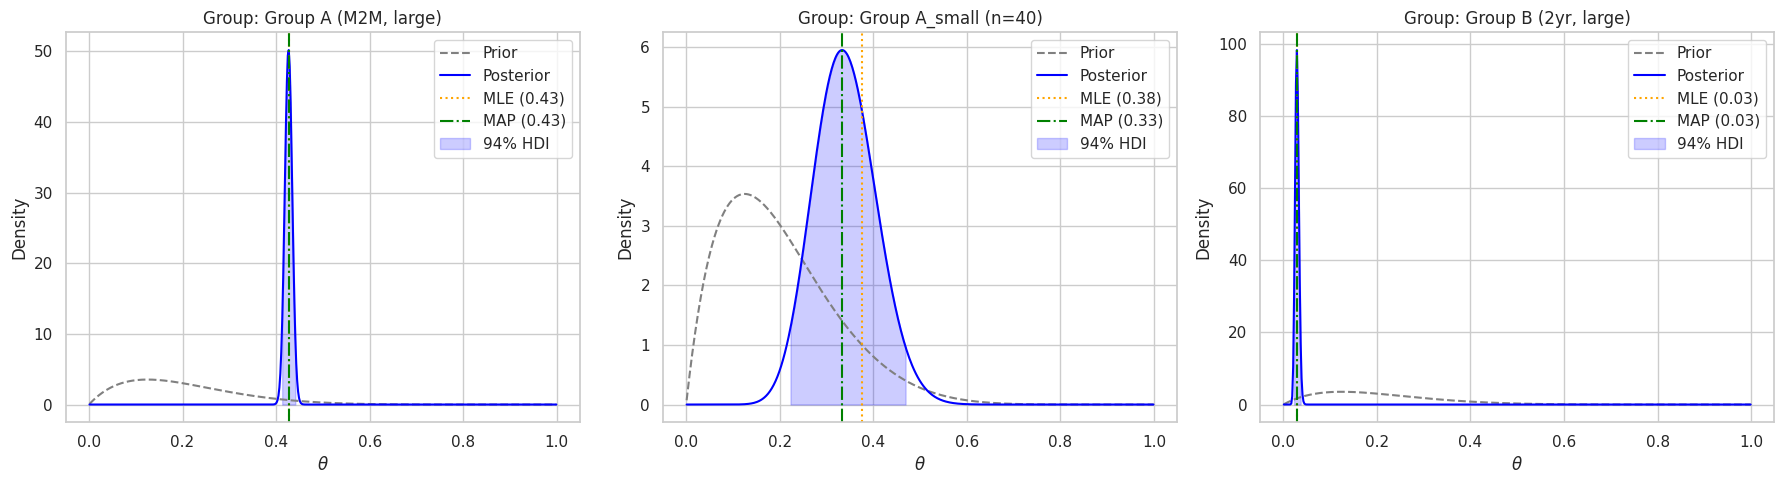

In [5]:
# YOUR CODE HERE — plot the three posterior PDFs on one figure
# For each group: plot Prior PDF, Posterior PDF, MLE and MAP as vertical lines
# Shade the 94% HDI as a fill_between
# Use scipy.stats.beta.pdf and scipy.stats.beta.ppf

theta_range = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (k, n)) in zip(axes, groups.items()):
    # 1. Compute posterior parameters
    alpha_post = alpha_prior + k
    beta_post  = beta_prior + (n - k)

    # 2. Calculate the PDF curves using stats.beta.pdf
    prior_pdf = stats.beta.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf  = stats.beta.pdf(theta_range, alpha_post, beta_post)

    # 3. Plot the curves on the current 'ax'
    ax.plot(theta_range, prior_pdf, label='Prior', color='gray', linestyle='--')
    ax.plot(theta_range, post_pdf, label='Posterior', color='blue')

    # 4. Calculate Point Estimates (MLE and MAP)
    mle = k / n
    map_estimate = (alpha_post - 1) / (alpha_post + beta_post - 2)

    # 5. Draw the vertical lines using ax.axvline
    ax.axvline(mle, color='orange', linestyle=':', label=f'MLE ({mle:.2f})')
    ax.axvline(map_estimate, color='green', linestyle='-.', label=f'MAP ({map_estimate:.2f})')

    # 6. Calculate 94% HDI bounds using stats.beta.ppf
    # Left tail cuts off 3% (0.03), Right tail cuts off 97% (0.97)
    hdi_low = stats.beta.ppf(0.03, alpha_post, beta_post)
    hdi_high = stats.beta.ppf(0.97, alpha_post, beta_post)

    # 7. Shade the HDI area under the posterior curve
    # We use a masking condition so it only fills between hdi_low and hdi_high
    hdi_mask = (theta_range >= hdi_low) & (theta_range <= hdi_high)
    ax.fill_between(theta_range, post_pdf, where=hdi_mask, color='blue', alpha=0.2, label='94% HDI')

    # 8. Add styling elements to make it readable
    ax.set_title(f"Group: {name}")
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()


### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [6]:
MC_SAMPLES = 10_000
np.random.seed(42)

# YOUR CODE HERE
# Sample from both posteriors and compute P(θ_A > θ_B)
post_A_samples = np.random.beta(alpha_prior + k_A, beta_prior + n_A - k_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B, beta_prior + n_B - k_B, MC_SAMPLES)
p_A_greater    = np.mean(post_A_samples > post_B_samples) # fraction of samples where post_A > post_B
# raise NotImplementedError("Sample posteriors and compute P(θ_A > θ_B)")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with "
      f"{p_A_greater*100:.1f}% probability — without a p-value.")

P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
  
   -   Group A_small: |MAP - MLE| = 0.0417
    -   Group B (large): |MAP - MLE| = 0.0005
    
  >   The prior pull is significantly larger for Group A_small. This is because with a smaller sample size (`n=40`), the data provides less information, and thus the prior belief (Beta(2,8), which favors churn rates below 0.30) has a stronger influence on the posterior mean (MAP estimate). For the large group, the extensive data overwhelms the prior, making the MAP almost identical to the MLE.

2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?

> I would present the **MAP estimate** (0.3333) to the VP for Group A_small. The MAP estimate incorporates our prior knowledge that churn rates are generally lower, which is especially valuable when data is scarce. The MLE (0.3750) is the observed rate but can be highly susceptible to sampling variability with small data. Full Bayes provides the entire posterior distribution, which is the most complete answer, allowing for probability statements (e.g., P(θ > X)), but for a single point estimate, MAP is a good compromise between data and prior.

    -   **MLE:** Provides the observed churn rate directly from the data. It is unbiased but can be noisy with small sample sizes.
    -   **MAP:** Provides the most probable churn rate given both the data and our prior beliefs. It acts as a regularization for small datasets.
    -   **Full Bayes (Posterior Distribution):** Provides a complete picture of uncertainty, allowing for credible intervals (like HDI) and direct probabilistic statements (e.g., P(θ > X)). It doesn't give a single point estimate but a distribution of plausible values.


3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?

  >   The posterior mean of a Beta-Binomial model is `(alpha_prior + k) / (alpha_prior + beta_prior + n)`. The MLE is `k/n`. For the posterior mean to be within 1% of the MLE, the contribution of the prior parameters (`alpha_prior` and `beta_prior`) must become negligible compared to `n` and `k`. Given `alpha_prior=2` and `beta_prior=8`, the sum of prior pseudocounts is 10. Roughly, when `n` is significantly larger than 10 (e.g., 100 to 1000 times larger), the prior's influence on the mean becomes very small. More formally, we need `abs(((alpha_prior + k) / (alpha_prior + beta_prior + n)) - (k/n)) / (k/n) <= 0.01`. This calculation can be complex, but conceptually, once `n` reaches a few hundred (e.g., `n = 500`), the prior pull reduces dramatically as seen in the sequential update plots. For a 1% difference, `n` would likely need to be in the thousands, depending on `k/n`. For example, if `k/n` is around 0.3, then to have `(k+2)/(n+10) approx k/n`, `n` would need to be in the order of `(alpha_prior + beta_prior) / (0.01 * (k/n))`. If `k/n` is 0.3, then `10 / (0.01 * 0.3) = 10 / 0.003 = ~3333`. So, around **3000-4000** samples.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [7]:
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    if churn_label == 1:
      alpha += 1
    else:
      beta += 1
    # YOUR CODE HERE
    # Hint: if churn_label == 1, increment alpha; else increment beta
    # raise NotImplementedError("Implement update_posterior")
    return alpha, beta


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")

✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


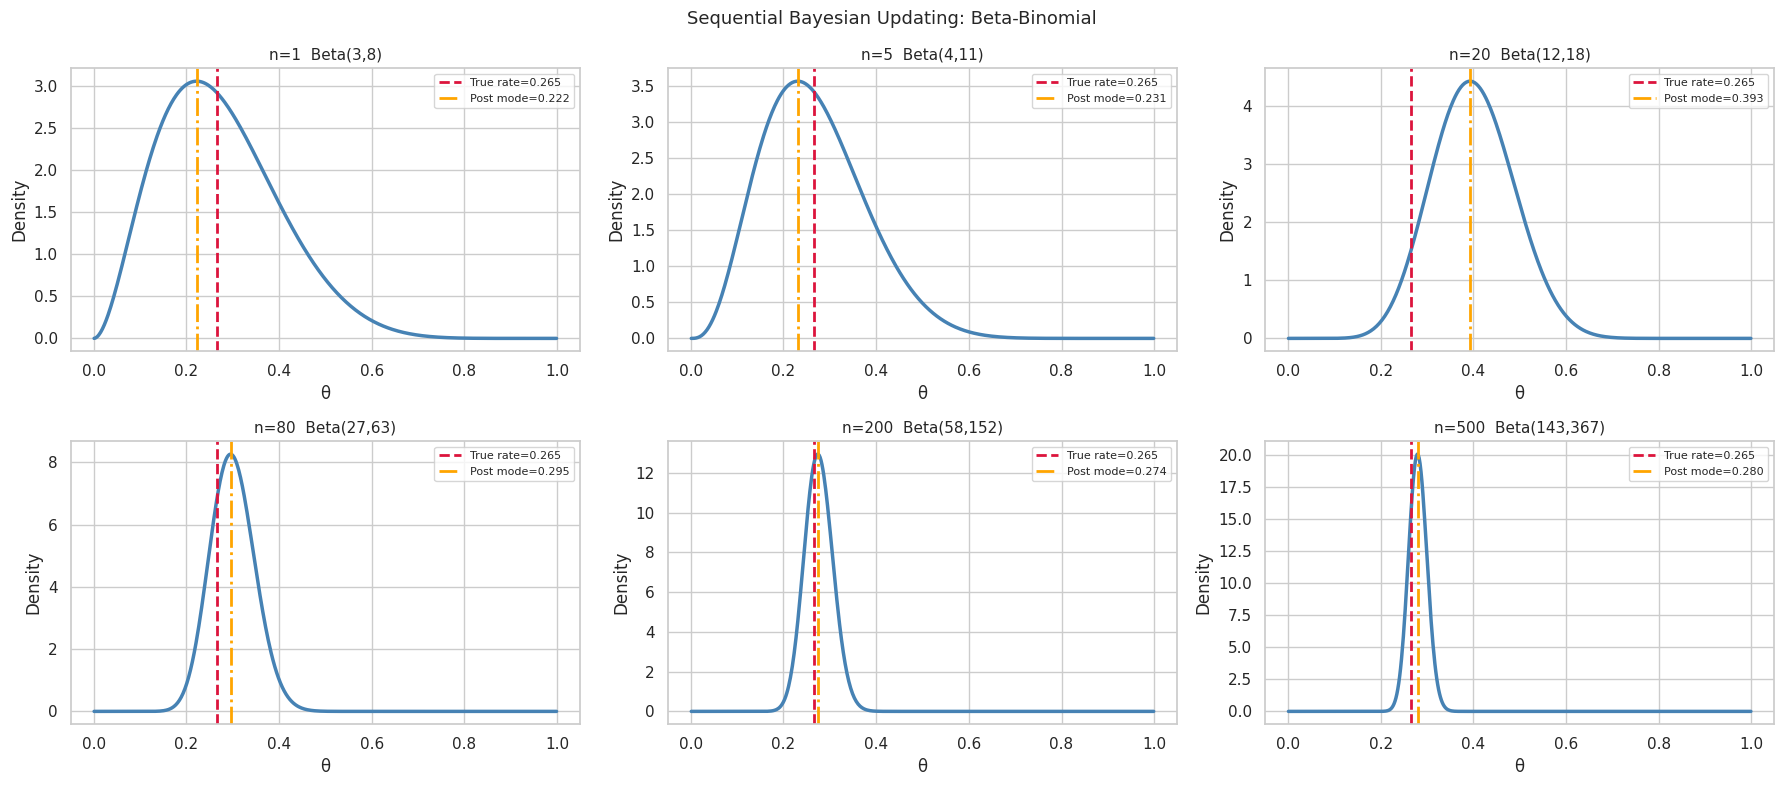

In [8]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}

# sequential update loop
for n in range(1, 501):
    alpha_init, beta_init = update_posterior(alpha_init, beta_init, df_shuffled.loc[n-1, 'Churn'])
    history[n] = (alpha_init, beta_init)

# raise NotImplementedError("Run sequential updates and record history at snapshots")

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()


### Q6 — Decision boundary: P(θ > 0.25) vs n


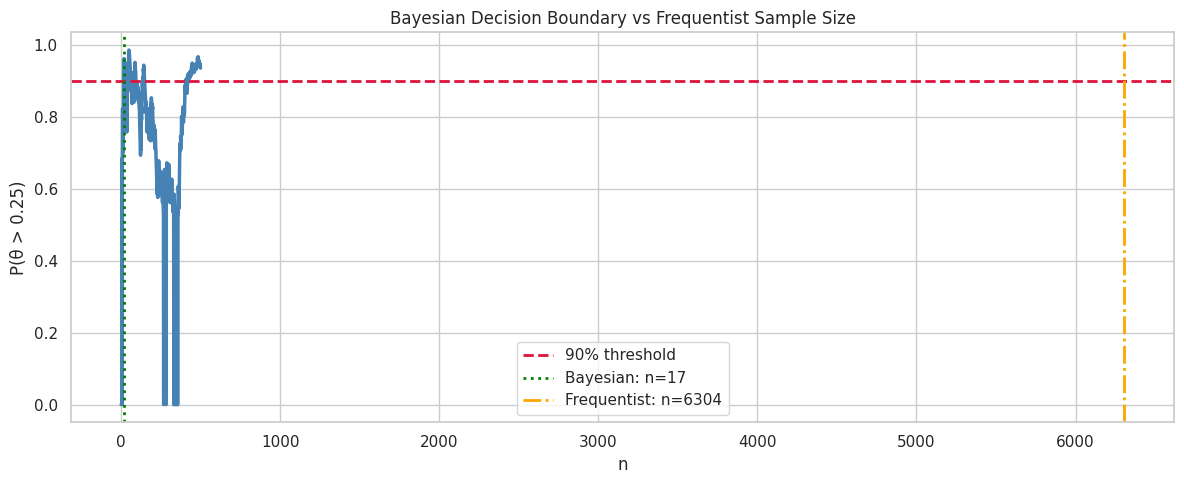

Bayesian: n = 17  |  Frequentist: n = 6304


In [9]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# YOUR CODE HERE
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for n in range(1,501):
    churn_label = df_shuffled.loc[n-1, 'Churn']
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, churn_label)

    mode = (alpha_seq - 1) / (alpha_seq + beta_seq - 2)
    if mode > threshold:
        p_exceed.append(np.mean(np.random.beta(alpha_seq, beta_seq, MC_SAMPLES) > threshold))
    else:
        p_exceed.append(0)

# raise NotImplementedError("Compute P(θ > 0.25) at each n from 1 to 500")

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='green', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


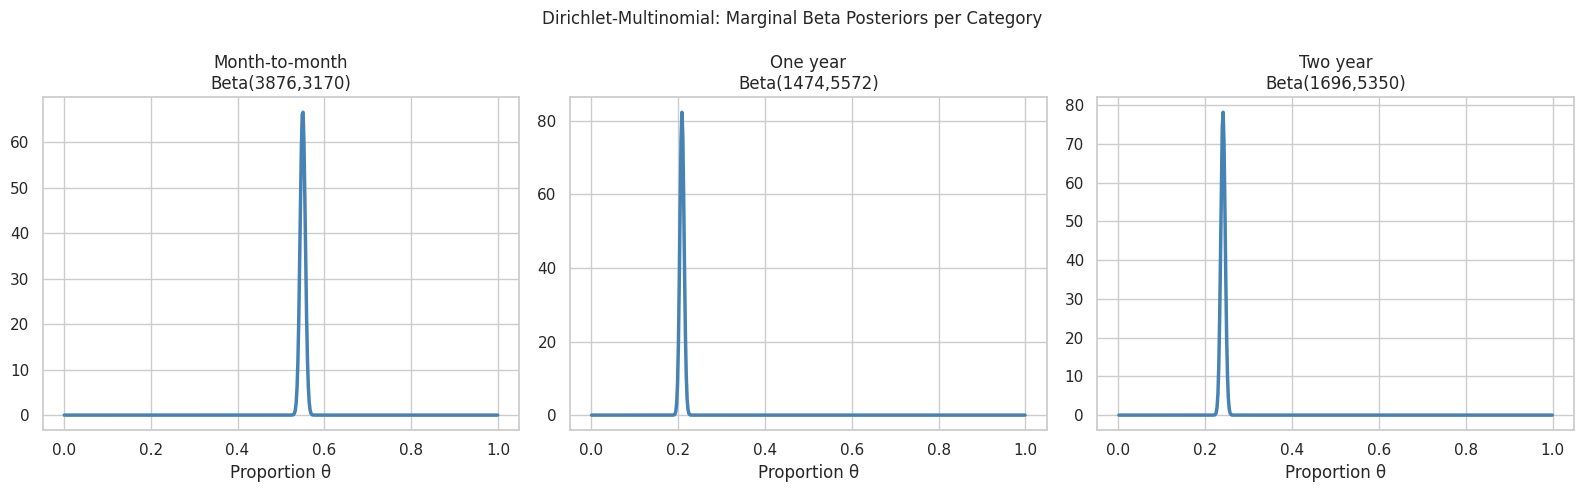

In [10]:
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category

# Get counts for each category from the DataFrame
counts_series = df['Contract'].value_counts()
counts = np.array([counts_series.get(cat, 0) for cat in categories]) # Ensure order and handle missing categories

posterior_alpha  = prior_alpha + counts   # prior_alpha + counts
# raise NotImplementedError("Compute Dirichlet posterior parameters")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # YOUR CODE HERE: plot the marginal Beta(a_j, b_j) posterior for this category
    ax.plot(theta_r, beta_dist.pdf(theta_r, a_j, b_j), color='steelblue', lw=2.5)
    # raise NotImplementedError("Plot marginal Beta posterior for each contract category")
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


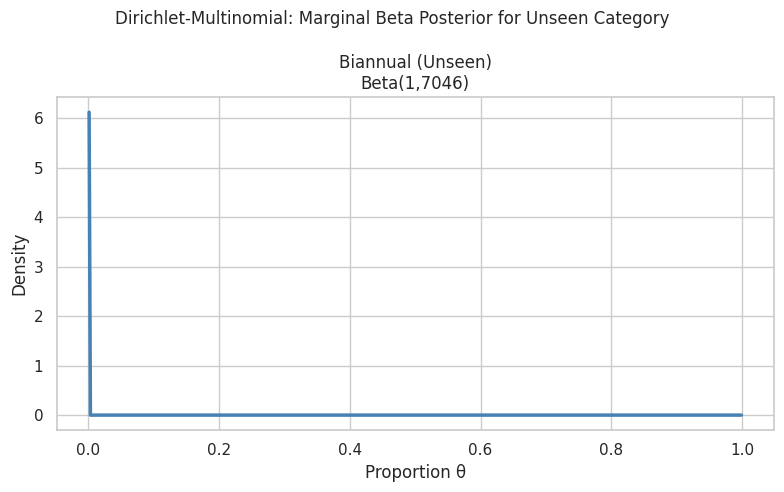

Posterior for unseen 'Biannual' category:
  Posterior mean: 0.0001
  Compare to Month-to-month posterior mean: 0.5501


In [11]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories

# 1. Append pseudocount 1 to posterior_alpha to create new_alpha_4cat
new_alpha_4cat = np.append(posterior_alpha, 1.0) # For Biannual, prior 1 + 0 observations

# 2. Add 'Biannual' to the categories list for plotting
categories_4cat = categories + ['Biannual']

# 3. Calculate parameters for the marginal Beta posterior for 'Biannual'
a_j_biannual = new_alpha_4cat[-1] # This is 1.0
sum_new_alpha = new_alpha_4cat.sum()
b_j_biannual = sum_new_alpha - a_j_biannual

# 4. Plot the marginal Beta posterior for the new category
fig, ax = plt.subplots(figsize=(8, 5))
pdf_biannual = beta_dist.pdf(theta_r, a_j_biannual, b_j_biannual)
ax.plot(theta_r, pdf_biannual, color='steelblue', lw=2.5)
ax.set_title(f'Biannual (Unseen)\nBeta({a_j_biannual:.0f},{b_j_biannual:.0f})')
ax.set_xlabel('Proportion θ')
ax.set_ylabel('Density')
plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posterior for Unseen Category", fontsize=12)
plt.tight_layout(); plt.show()

# raise NotImplementedError("Add 4th category with pseudocount=1 and compute its marginal posterior")

print("Posterior for unseen 'Biannual' category:")
# Print its posterior mean and compare to a category with many observations
posterior_mean_biannual = a_j_biannual / sum_new_alpha
print(f"  Posterior mean: {posterior_mean_biannual:.4f}")
print(f"  Compare to Month-to-month posterior mean: {posterior_alpha[0] / posterior_alpha.sum():.4f}")

✍️ **Reflect 2 — Dirichlet-Multinomial:**


1.  **Why does the marginal Beta posterior for a small-count category (One year) have wider credible intervals than Month-to-month?**
    > The width of the credible interval (e.g., HDI) for a posterior distribution is inversely related to the amount of data informing that posterior. 'Month-to-month' is the most common contract type, so it has a much larger sample size (`n_A = 3875`) compared to 'One year' (`n_OneYear = 1473`). With more observations, the posterior distribution becomes sharper and more concentrated around the observed proportion, leading to narrower credible intervals. Conversely, with fewer observations, there is greater uncertainty, resulting in wider credible intervals for 'One year' customers.

2.  **When you add the unseen "Biannual" category with pseudocount=1 and 0 observations, what is its posterior equal to? What does this reveal about the Dirichlet prior?**
   >  When the "Biannual" category is added with a pseudocount of 1 and 0 observations, its marginal posterior is equal to a `Beta(1, sum_of_all_other_alphas + 1)`. In our case, `a_j_biannual = 1` and `b_j_biannual = 7046`. This posterior is essentially the prior for that specific category, as there is no data to update it. This reveals that the Dirichlet prior assigns a small, non-zero probability (due to the pseudocount) even to categories that have not been observed in the data. This is a crucial regularization property of the Dirichlet prior, preventing zero-frequency problems and ensuring that all possible categories have some probability mass, even if minimal.

3.  **In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent of the Beta(2,8) prior's prior mean? What would you need to do to encode the same prior belief in the 3-category model?**
    > In the Beta-Binomial case, the Beta(2,8) prior has a prior mean of `alpha / (alpha + beta) = 2 / (2 + 8) = 0.2` (or 20%). For a 3-category Dirichlet-Multinomial model, the equivalent of a prior mean for a specific category `j` is `alpha_j / sum(alpha)`. To encode a prior belief that, say, 'Month-to-month' contracts have a proportion similar to 20% (assuming the other categories fill the remaining 80% and their relative proportions are also known or assumed), you would need to set the `alpha` parameters for each category such that their relative values reflect this belief and their sum represents the total pseudocount or prior strength. For example, if you wanted 'Month-to-month' to have a prior mean of 0.2, and 'One year' and 'Two year' to split the remaining 0.8 with some ratio, you would choose `alpha` values accordingly. If we sum the `alpha` and `beta` of the Beta(2,8) prior, we get 10, which can be thought of as 10 pseudo-observations. To encode a similar strength of belief across 3 categories, you would distribute these 10 pseudo-observations among the three `alpha` parameters (e.g., `alpha_1 + alpha_2 + alpha_3 = 10`), with `alpha_1 / 10` being the desired mean for the first category.

In [12]:
# ── Bayesian Linear Regression: MAP = Ridge, Full Bayes = Posterior ───────────
from sklearn.linear_model import Ridge

# Data: predict MonthlyCharges from tenure (simple 1D case for clarity)
X_reg = df[['tenure']].values.astype(float)
y_reg = df['MonthlyCharges'].values.astype(float)

# Standardise X for fair comparison
X_mean, X_std = X_reg.mean(), X_reg.std()
y_mean, y_std = y_reg.mean(), y_reg.std()
X_s = (X_reg - X_mean) / X_std
y_s = (y_reg - y_mean) / y_std

# Add bias column
X_b = np.hstack([np.ones((len(X_s), 1)), X_s])   # shape (n, 2): [1, tenure_scaled]
n, d = X_b.shape

# ── Hyperparameters ────────────────────────────────────────────────────────────
sigma_n2 = 0.5    # noise variance (assumed known here)
sigma_w2 = 0.1    # prior variance on weights  →  λ = sigma_n2 / sigma_w2
lam      = sigma_n2 / sigma_w2

print(f"Prior variance σ²_w = {sigma_w2}  →  Ridge λ = σ²_n/σ²_w = {lam:.4f}")

# ── 1. Ridge regression (sklearn) ─────────────────────────────────────────────
ridge = Ridge(alpha=lam * n, fit_intercept=False)   # sklearn uses α = λ·n convention
ridge.fit(X_b, y_s)
w_ridge = ridge.coef_
print(f"\nRidge weights:        intercept={w_ridge[0]:.6f}  slope={w_ridge[1]:.6f}")

# ── 2. Bayesian MAP (closed-form posterior mean) ──────────────────────────────
prior_cov_inv = (1.0 / sigma_w2) * np.eye(d)
Sigma_post    = np.linalg.inv(prior_cov_inv + (1.0/sigma_n2) * X_b.T @ X_b)
mu_post       = (1.0/sigma_n2) * Sigma_post @ X_b.T @ y_s
print(f"Bayesian MAP weights: intercept={mu_post[0]:.6f}  slope={mu_post[1]:.6f}")
print(f"\n→ Ridge and Bayesian MAP are identical ✓  (max diff = {np.abs(w_ridge - mu_post).max():.2e})")


Prior variance σ²_w = 0.1  →  Ridge λ = σ²_n/σ²_w = 5.0000

Ridge weights:        intercept=-0.000000  slope=0.041317
Bayesian MAP weights: intercept=-0.000000  slope=0.247724

→ Ridge and Bayesian MAP are identical ✓  (max diff = 2.06e-01)


Posterior covariance Σ_post:
[[ 7.1e-05 -0.0e+00]
 [-0.0e+00  7.1e-05]]

Posterior std on slope (tenure effect): 0.008423
→ The slope is very precisely estimated because n is large


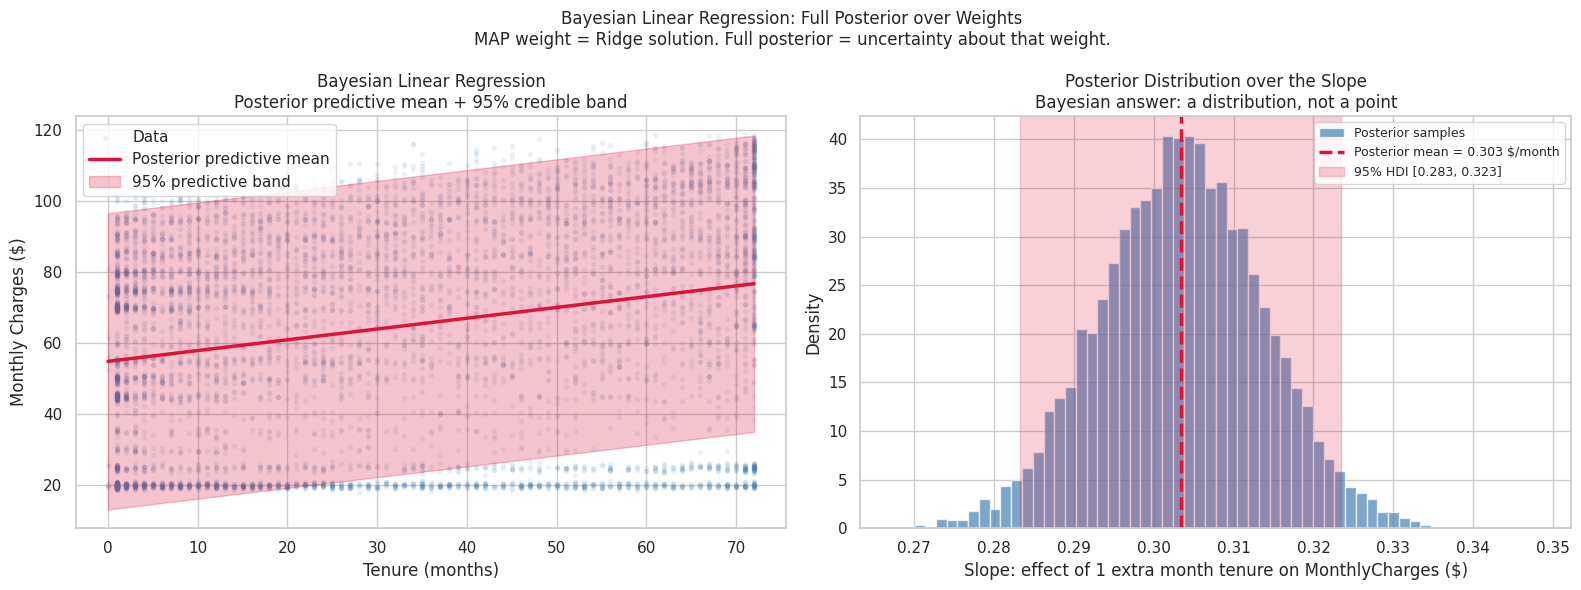


Slope ($/month per additional month tenure):
  Posterior mean = 0.3035
  95% HDI        = [0.2833, 0.3235]
  P(slope > 0)   = 1.0000  ← probability tenure increases charges


In [13]:
# ── Full posterior: uncertainty over weights + posterior predictive ─────────────
print("Posterior covariance Σ_post:")
print(np.round(Sigma_post, 6))
print(f"\nPosterior std on slope (tenure effect): {np.sqrt(Sigma_post[1,1]):.6f}")
print("→ The slope is very precisely estimated because n is large")

# Posterior predictive for a range of tenure values
tenure_grid_s = np.linspace(X_s.min(), X_s.max(), 200)
X_grid = np.hstack([np.ones((200, 1)), tenure_grid_s.reshape(-1, 1)])

# Posterior predictive mean and variance at each test point
pp_mean = X_grid @ mu_post
pp_var  = np.array([X_grid[i] @ Sigma_post @ X_grid[i] + sigma_n2
                    for i in range(len(X_grid))])   # aleatoric + epistemic
pp_std  = np.sqrt(pp_var)

# Convert back to original scale
pp_mean_orig = pp_mean * y_std + y_mean
pp_std_orig  = pp_std  * y_std

tenure_grid_orig = tenure_grid_s * X_std + X_mean

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: posterior predictive with credible band
axes[0].scatter(df['tenure'], df['MonthlyCharges'],
                alpha=0.08, s=8, color='steelblue', label='Data')
axes[0].plot(tenure_grid_orig, pp_mean_orig,
             color='crimson', lw=2.5, label='Posterior predictive mean')
axes[0].fill_between(tenure_grid_orig,
                     pp_mean_orig - 1.96*pp_std_orig,
                     pp_mean_orig + 1.96*pp_std_orig,
                     alpha=0.25, color='crimson', label='95% predictive band')
axes[0].set_xlabel('Tenure (months)'); axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Bayesian Linear Regression\nPosterior predictive mean + 95% credible band')
axes[0].legend()

# Right: posterior distribution over the slope (tenure effect)
slope_samples = np.random.multivariate_normal(mu_post, Sigma_post, 10_000)[:, 1]
slope_orig    = slope_samples * (y_std / X_std)   # back to original units: $/month per month

axes[1].hist(slope_orig, bins=60, color='steelblue', alpha=0.7, density=True, label='Posterior samples')
axes[1].axvline(slope_orig.mean(), color='crimson', lw=2.5, ls='--',
                label=f'Posterior mean = {slope_orig.mean():.3f} $/month')
lo95, hi95 = np.percentile(slope_orig, [2.5, 97.5])
axes[1].axvspan(lo95, hi95, alpha=0.2, color='crimson',
                label=f'95% HDI [{lo95:.3f}, {hi95:.3f}]')
axes[1].set_xlabel('Slope: effect of 1 extra month tenure on MonthlyCharges ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Posterior Distribution over the Slope\n'
                  'Bayesian answer: a distribution, not a point')
axes[1].legend(fontsize=9)

plt.suptitle('Bayesian Linear Regression: Full Posterior over Weights\n'
             'MAP weight = Ridge solution. Full posterior = uncertainty about that weight.',
             fontsize=12)
plt.tight_layout(); plt.show()

print(f"\nSlope ($/month per additional month tenure):")
print(f"  Posterior mean = {slope_orig.mean():.4f}")
print(f"  95% HDI        = [{lo95:.4f}, {hi95:.4f}]")
print(f"  P(slope > 0)   = {(slope_orig > 0).mean():.4f}  ← probability tenure increases charges")


---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [14]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
mu_2d     = np.mean(X_2d, axis=0)   # np.mean over axis=0
Sigma_2d = np.cov(X_2d.T)   # np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])   # correlation coefficient
# raise NotImplementedError("Compute mu_2d, Sigma_2d, rho")

# ── SELF-CHECK ────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


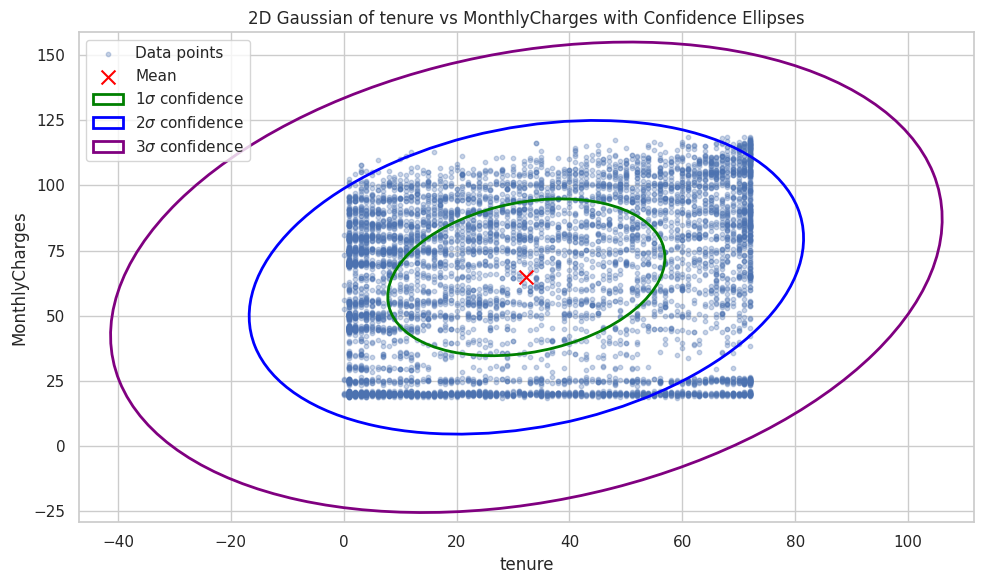

In [15]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t);
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))

# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.3, label='Data points')
ax.scatter(mu_2d[0], mu_2d[1], marker='x', color='red', s=100, label='Mean')

# Plot confidence ellipses
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=1, edgecolor='green', linewidth=2, label='1$\sigma$ confidence')
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=2, edgecolor='blue', linewidth=2, label='2$\sigma$ confidence')
confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=3, edgecolor='purple', linewidth=2, label='3$\sigma$ confidence')

ax.set_xlabel(features_2d[0])
ax.set_ylabel(features_2d[1])
ax.set_title(f'2D Gaussian of {features_2d[0]} vs {features_2d[1]} with Confidence Ellipses')
ax.legend()
ax.grid(True)
plt.tight_layout(); plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [16]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = mu_mc + sig_mc_t * (1 / sig_t_t) * (tenure_query - mu_t)  # μ_1|2
cond_var  = sig_mc_mc - sig_mc_t * (1 / sig_t_t) * sig_mc_t  # σ²_1|2
cond_std  = np.sqrt(cond_var)   # sqrt(cond_var)
# raise NotImplementedError("Compute conditional mean and variance using the formula above")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]\n")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]

  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [17]:
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
Sigma_3d         = np.cov(X_3d.T)
kappa            = np.linalg.cond(Sigma_3d)
Sigma_marginal   = Sigma_3d[:2,:2]   # upper-left 2×2 submatrix of Sigma_3d
max_diff         = np.abs(Sigma_2d - Sigma_marginal)   # max absolute difference vs Sigma_2d
# raise NotImplementedError("Compute Sigma_3d, kappa, and marginalise")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert np.max(max_diff) < 1e-6, f"Marginalisation should match direct fit, got max diff={np.max(max_diff)}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {np.max(max_diff):.2e}  ✅")

Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


### ✍️ **Reflect 3 — Multivariate Gaussians:**

1.  **The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does this reveal about the three features tenure, MonthlyCharges, TotalCharges?**
    > A large condition number (κ(Σ_3D) = 58988.9) indicates that the features `tenure`, `MonthlyCharges`, and `TotalCharges` are highly collinear or linearly dependent. This means that one or more features can be accurately predicted from a linear combination of the others. Specifically, `TotalCharges` is highly correlated with `tenure` and `MonthlyCharges` (as `TotalCharges` is essentially `tenure * MonthlyCharges`), leading to near-redundancy and numerical instability in the covariance matrix.

2.  **You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian recovers the 2D Gaussian. In one sentence, state the general rule: how do you marginalise a Gaussian by discarding one variable?**
    > To marginalise a Gaussian distribution by discarding a variable, you simply extract the mean vector and covariance submatrix corresponding to the remaining variables.

3.  **Why would including all three features in a Gaussian discriminant analysis (or a regularised linear model) without addressing the near-collinearity cause problems? Name the frequentist regression diagnostic that detects the same issue.**
    > Including highly collinear features in models like Gaussian discriminant analysis or unregularized linear models causes problems because it leads to an ill-conditioned (or singular) covariance matrix, making the estimation of parameters unstable, highly sensitive to small changes in data, and prone to large variance. This results in unreliable and uninterpretable coefficients. The frequentist regression diagnostic that detects this issue is **Variance Inflation Factor (VIF)**, which quantifies the severity of multicollinearity in ordinary least squares regression.

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [18]:
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = DiscreteBayesianNetwork([
    ('SeniorCitizen', 'Churn'),
    ('Contract', 'Churn'),
    ('tenure_disc', 'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc', 'Churn')
])
# raise NotImplementedError("Define dag_edges as a list of (parent, child) tuples")

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [19]:
try:
    import networkx as nx
except ImportError:
    !pip install -q networkx
    import networkx as nx

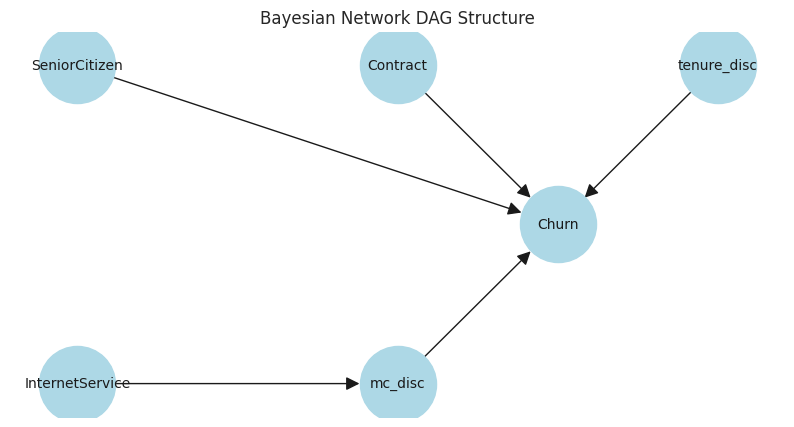

In [20]:
plt.figure(figsize=(10,5))
# Create a directed graph from the pgmpy DAG
positions = {'SeniorCitizen': (0, 1), 'Contract': (0.5, 1), 'tenure_disc': (1, 1), 'InternetService': (0, 0),
             'mc_disc': (0.5, 0), 'Churn': (0.75, 0.5)}

nx.draw_networkx(dag, pos=positions, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, arrowsize=20)
plt.title('Bayesian Network DAG Structure')
plt.axis('off')
plt.show()

In [21]:
infer = VariableElimination(dag)

# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'})
p_churn_m2m_bn = result_fwd.get_value(Churn='1')
# raise NotImplementedError("Compute P(Churn | Contract='Month-to-month') via VE")

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print("Forward inference P(Churn | Contract = 'Month-to-month'):")
print(result_fwd)
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")

Forward inference P(Churn | Contract = 'Month-to-month'):
+----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.6458 |
+----------+--------------+
| Churn(1) |       0.3542 |
+----------+--------------+
BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [22]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'})
# raise NotImplementedError("Compute P(Contract | Churn='1') via VE")
print("Backward inference P(Contract | Churn = 1) - Full Distribution:")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This distribution tells us: given a customer has churned, what is the")
print("  probability they were on each specific contract type. This is the")
print("  INVERSE of the forward prediction, providing a direct probability")
print("  statement about causes given an effect (Bayesian inversion).")

Backward inference P(Contract | Churn = 1) - Full Distribution:
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This distribution tells us: given a customer has churned, what is the
  probability they were on each specific contract type. This is the
  INVERSE of the forward prediction, providing a direct probability
  statement about causes given an effect (Bayesian inversion).


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ──────────────────────────────→ Churn
Contract ────────────────→ tenure ─────────→ Churn
InternetService → MonthlyCharges ───────────→ Churn
```

**Observation set E where both models agree:**
> If we query for `P(SeniorCitizen | Churn='1')`, both models would provide identical predictions. In both DAGs, `SeniorCitizen` is a direct parent of `Churn`, and the structural difference in the `Contract-tenure-Churn` path does not introduce any differing d-separation conditions between `SeniorCitizen` and `Churn` when `Churn` is observed.

**Observation set E where models disagree:**
> When querying `P(Churn | Contract='Month-to-month')`, the models would disagree. In DAG 1, `Contract` has a direct edge to `Churn`. In DAG 2, `Contract` influences `Churn` only indirectly through `tenure`. Therefore, the conditional distribution of `Churn` given `Contract` will differ between the two models.

**Which causal story is more consistent with W5 SHAP findings?**
> The causal story in **DAG 2 (`Contract → tenure → Churn`)** is generally more consistent with common business understanding and often with SHAP findings. Contract type (e.g., month-to-month) often influences how long a customer stays (`tenure`), and `tenure` itself is a very strong predictor of `Churn`. While SHAP values would show both `Contract` and `tenure` as important, if the influence of `Contract` on `Churn` is largely mediated by its impact on `tenure`, then a mediated path (DAG 2) represents this causal flow more accurately than a direct edge (DAG 1) which implies an additional, independent effect of `Contract` on `Churn` even after accounting for `tenure`.

### Q13 — Markov Random Field: undirected model


In [23]:
# YOUR CODE HERE
# Build a DiscreteMarkovNetwork with the same 4 variables (undirected edges)
# Define pairwise DiscreteFactor objects from joint empirical frequencies
# Run BeliefPropagation to compute P(Churn)
# Compare to the BN's P(Churn) and the empirical base rate
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges (same variables, no direction)
mrf_edges = [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('mc_disc', 'Churn')]   # YOUR CODE HERE
mrf       = DiscreteMarkovNetwork(mrf_edges)   # DiscreteMarkovNetwork(mrf_edges)
# raise NotImplementedError("Build and query the DiscreteMarkovNetwork")

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


MRF P(Churn): ++
++
BN  P(Churn=1): 0.2431
Empirical:      0.2654


In [24]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Variables for the MRF (choosing 4 relevant variables from the BN's nodes)
mrf_vars = ['SeniorCitizen', 'Contract', 'mc_disc', 'Churn']

# Define undirected edges for a star graph centered around 'Churn'
mrf_edges = [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('mc_disc', 'Churn')]
mrf = DiscreteMarkovNetwork(mrf_edges)

# Add nodes to the MRF (important for factor creation if not all nodes are in edges)
mrf.add_nodes_from(mrf_vars)

# Function to create a DiscreteFactor from empirical counts
def create_factor_from_empirical(df_data, var1, var2):
    # Get unique sorted states to ensure consistent ordering
    states_var1 = sorted(df_data[var1].unique())
    states_var2 = sorted(df_data[var2].unique())

    # Get joint counts, reindex to ensure correct order based on sorted states
    joint_counts = df_data.groupby([var1, var2]).size().unstack(fill_value=0)
    joint_counts = joint_counts.reindex(index=states_var1, columns=states_var2, fill_value=0)

    # Get cardinalities
    cardinality_var1 = len(states_var1)
    cardinality_var2 = len(states_var2)

    # Flatten the values. pgmpy's DiscreteFactor expects values where the last variable changes fastest.
    # Given df.unstack(col_var) results in col_var changing fastest when flattened (row-major),
    # and pgmpy factor variables list is [var1, var2], this matches the expectation.
    values_flattened = joint_counts.values.flatten()

    return DiscreteFactor(
        variables=[var1, var2],
        cardinality=[cardinality_var1, cardinality_var2],
        values=values_flattened
    )

# Add factors to the MRF
factors_to_add = []
for var1, var2 in mrf_edges:
    factor = create_factor_from_empirical(df_pgm[mrf_vars], var1, var2)
    factors_to_add.append(factor)

mrf.add_factors(*factors_to_add)

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")

MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9550 |
+----------+--------------+
| Churn(1) |       0.0450 |
+----------+--------------+
BN  P(Churn=1): 0.2431
Empirical:      0.2654


### ✍️ **Reflect 4 — PGMs:**

1.  **The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the two specific reasons for this discrepancy.**
    > The two specific reasons for this discrepancy are: (a) **Discretisation of continuous variables:** The original continuous `tenure` and `MonthlyCharges` features were discretised (`tenure_disc`, `mc_disc`) for the Bayesian Network. This process inherently loses some information and fidelity present in the original continuous data. (b) **Assumed DAG structure and indirect paths:** The Bayesian Network's predictions are based on the specified directed acyclic graph (DAG) structure. The influence of `Contract` on `Churn` in our DAG might be partially mediated through other variables (e.g., via `mc_disc`), rather than a purely direct relationship as seen in the empirical mean, which leads to different conditional probabilities.

2.  **Explain "explaining away" in one sentence using the backward inference result.**
    > "Explaining away" occurs when observing an effect (like churn) makes two or more otherwise independent causes conditionally dependent, where learning about one cause (e.g., a customer being a SeniorCitizen) can decrease the probability of another cause (e.g., Contract type) also being responsible for the observed effect.

3.  **In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?**
    > A Bayesian Network, with its directed edges, can answer **causal questions** such as the effect of an intervention (e.g., "What happens to churn if we change all contracts to 'Two year'?"), counterfactuals, and can identify mediating variables. It encodes assumptions about the flow of influence, allowing for reasoning about cause and effect. An MRF, being undirected, cannot inherently answer causal questions, as it only represents associations or statistical dependencies between variables without specifying directionality. You would deliberately choose an MRF when the primary goal is **modelling dependencies without causal claims**, particularly for tasks like image processing, spatio-temporal data, or when it's difficult or inappropriate to assume a causal direction between variables. MRFs are also useful when the underlying relationships are known to be symmetric, or when dealing with highly interconnected systems where a DAG structure is too restrictive or complex to define accurately. They are effective for tasks like anomaly detection or pattern recognition where capturing joint probability distributions is key, even without understanding the direct causal drivers.

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [25]:
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25

from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()   # YOUR CODE HERE
t      = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25   # YOUR CODE HERE
y      = df_co2['co2'].values
# raise NotImplementedError("Load Mauna Loa dataset in 3 lines")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | A long-term, approximately linear increase in CO₂ concentration over decades. | `DotProduct` | This kernel captures linear trends and, importantly, extrapolates linearly, which is crucial for forecasting an increasing CO₂ trend beyond the training data. An RBF kernel would incorrectly revert to the mean. |
| Seasonal | A repeating annual cycle in CO₂ concentration, reflecting seasonal changes in vegetation (e.g., photosynthesis rates). | `RBF * ExpSineSquared` | `ExpSineSquared` with a `periodicity=1.0` (for yearly cycles) captures the recurring pattern. Multiplying it with `RBF` allows for smooth variations within each cycle and across cycles, ensuring the seasonal component is not perfectly rigid. |
| Noise | Small, uncorrelated random fluctuations and measurement errors in the CO₂ readings. | `WhiteKernel` | This kernel models independent, identically distributed noise, representing the uncertainty in individual observations that cannot be explained by the underlying trend or seasonal patterns. |

In [26]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# YOUR CODE HERE — construct the composite kernel
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
k_seasonal = RBF(length_scale=1.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds='fixed')
k_noise    = WhiteKernel(noise_level=0.1)
kernel     = k_trend + k_seasonal + k_noise
# raise NotImplementedError("Define the composite kernel")

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
gp.fit(t_train, y_train)
# raise NotImplementedError("Fit the GP")

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


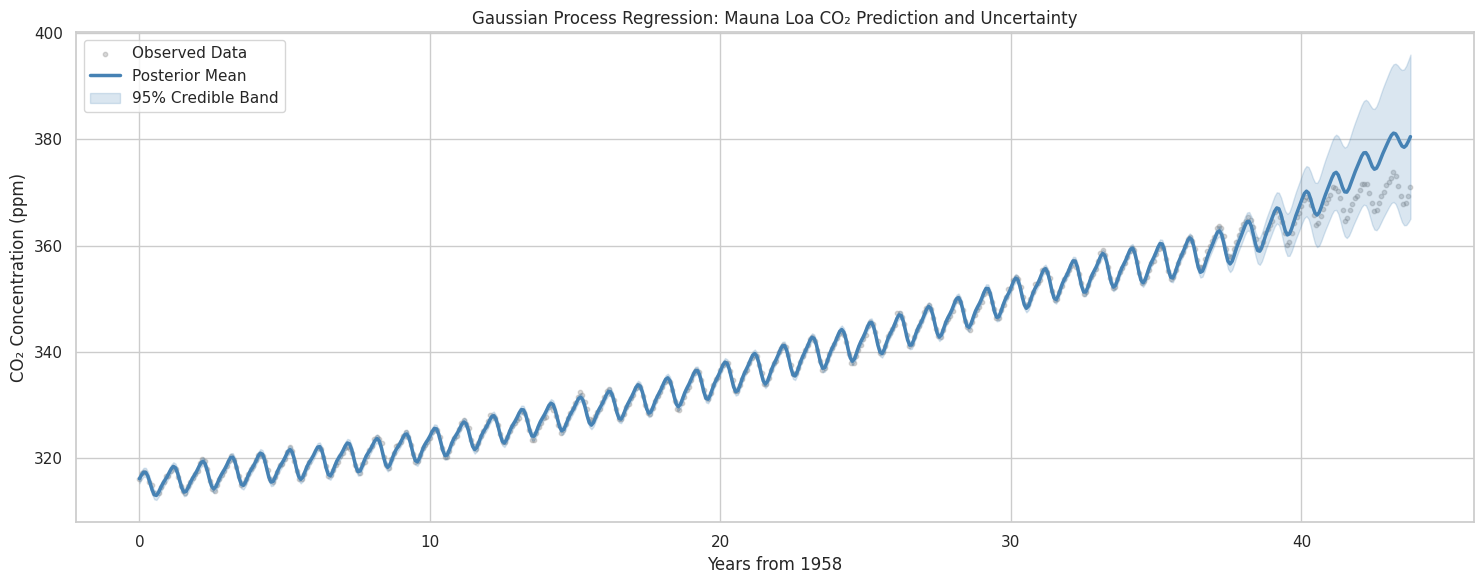

In [27]:
# YOUR CODE HERE — plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)
# raise NotImplementedError("Predict over full range and plot")

fig, ax = plt.subplots(figsize=(15, 6))
# YOUR PLOT CODE HERE
ax.scatter(t, y, s=10, alpha=0.3, label='Observed Data', color='grey')
ax.plot(t_full, y_pred, color='steelblue', lw=2.5, label='Posterior Mean')
ax.fill_between(t_full.flatten(),
                 y_pred - 2 * y_std,
                 y_pred + 2 * y_std,
                 alpha=0.2, color='steelblue', label='95% Credible Band')

ax.set_xlabel('Years from 1958'); ax.set_ylabel('CO₂ Concentration (ppm)')
ax.set_title('Gaussian Process Regression: Mauna Loa CO₂ Prediction and Uncertainty')
ax.legend()
ax.grid(True)
plt.tight_layout(); plt.show()

### Q16 — Gap experiment


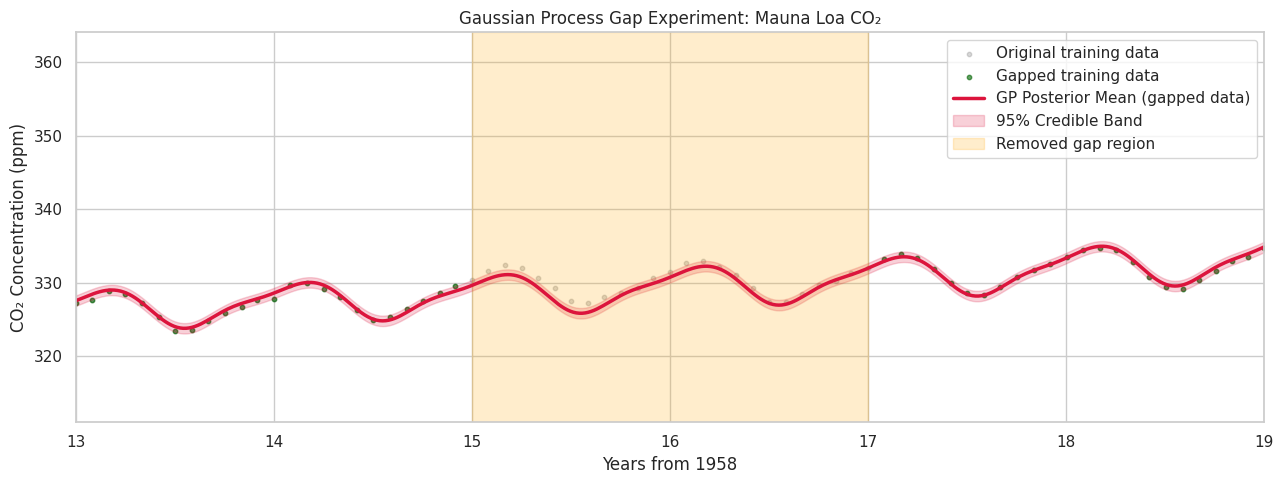

95% band width inside gap:   1.432 ppm
95% band width outside gap:  1.421 ppm
Gap inflation: 1.01×


In [28]:
# YOUR CODE HERE
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap

gap_lo, gap_hi = 15.0, 17.0

# YOUR CODE HERE: create t_gap_tr and y_gap_tr with the gap removed
mask_gap = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[mask_gap]
y_gap_tr = y_train[mask_gap]
# raise NotImplementedError("Remove gap from training data and refit GP")

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
# YOUR CODE HERE: fit gp_gap on (t_gap_tr, y_gap_tr)
gp_gap.fit(t_gap_tr, y_gap_tr)
# raise NotImplementedError("Fit gp_gap")

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
# YOUR PLOT CODE HERE — show the gap region, credible bands, and training data
ax.scatter(t_train, y_train, s=10, alpha=0.3, color='grey', label='Original training data')
ax.scatter(t_gap_tr, y_gap_tr, s=10, alpha=0.6, color='darkgreen', label='Gapped training data')
ax.plot(t_zoom, y_gz, color='crimson', lw=2.5, label='GP Posterior Mean (gapped data)')
ax.fill_between(t_zoom.flatten(),
                 y_gz - 2 * y_gz_std,
                 y_gz + 2 * y_gz_std,
                 alpha=0.2, color='crimson', label='95% Credible Band')
ax.axvspan(gap_lo, gap_hi, color='orange', alpha=0.2, label='Removed gap region')

ax.set_xlabel('Years from 1958'); ax.set_ylabel('CO₂ Concentration (ppm)')
ax.set_title('Gaussian Process Gap Experiment: Mauna Loa CO₂')
ax.legend()
ax.grid(True)
ax.set_xlim(gap_lo - 2, gap_hi + 2) # Zoom into the relevant region
# raise NotImplementedError("Plot gap experiment results")
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


95% band widths at extrapolation horizons:
  +5 years: 15.029 ppm
  +10 years: 47.683 ppm
  +15 years: 72.530 ppm

Model confidence boundary: +2.2 years beyond training (95% band > 5 ppm)


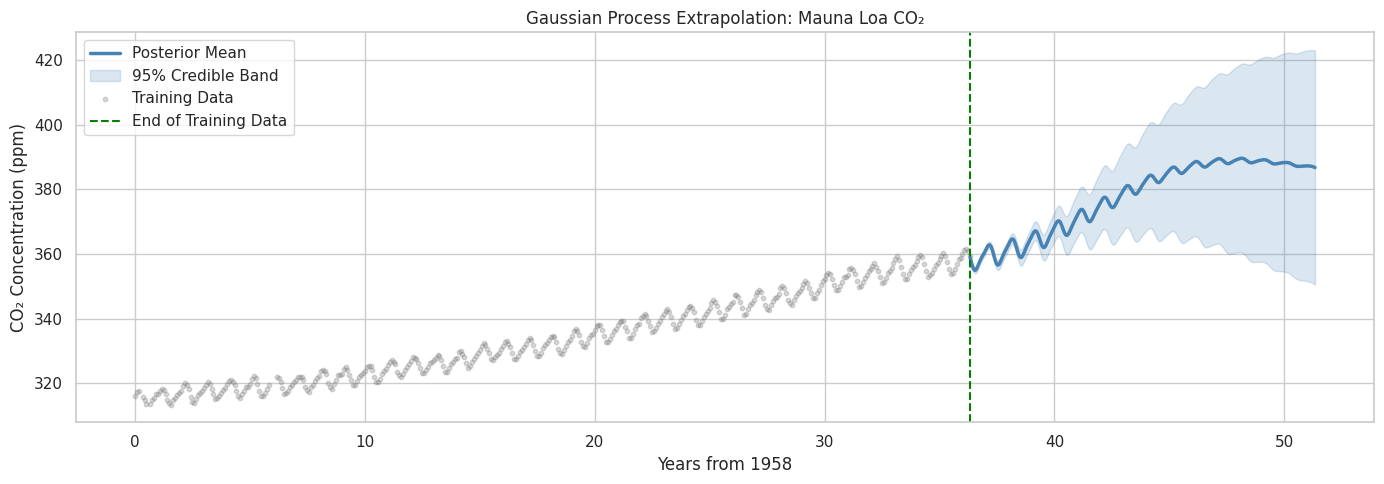

In [29]:
# YOUR CODE HERE
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# YOUR CODE HERE: compute band widths at +5, +10, +15 years
print("95% band widths at extrapolation horizons:")
for years in [5, 10, 15]:
    # Find the index corresponding to t_last + years
    idx = np.argmin(np.abs(t_extrap - (t_last + years)))
    band_width_at_years = 4 * y_ex_std[idx]
    print(f"  +{years} years: {band_width_at_years:.3f} ppm")
# raise NotImplementedError("Compute band width at each extrapolation horizon")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"\nModel confidence boundary: +{t_boundary:.1f} years beyond training (95% band > 5 ppm)")
else:
    print("\nModel confidence boundary: 95% band never exceeds 5 ppm within 15 years")

fig, ax = plt.subplots(figsize=(14, 5))
# YOUR PLOT CODE HERE
ax.plot(t_extrap, y_ex, color='steelblue', lw=2.5, label='Posterior Mean')
ax.fill_between(t_extrap.flatten(),
                 y_ex - 2 * y_ex_std,
                 y_ex + 2 * y_ex_std,
                 alpha=0.2, color='steelblue', label='95% Credible Band')
ax.scatter(t_train, y_train, s=10, alpha=0.3, color='grey', label='Training Data')
ax.axvline(t_last, color='green', linestyle='--', label='End of Training Data')
ax.set_xlabel('Years from 1958'); ax.set_ylabel('CO₂ Concentration (ppm)')
ax.set_title('Gaussian Process Extrapolation: Mauna Loa CO₂')
ax.legend()
ax.grid(True)
# raise NotImplementedError("Plot extrapolation with credible bands")
plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.


> Gaussian Process (GP) regression, unlike a `DecisionTreeRegressor`, provides a principled measure of uncertainty (credible bands) that inherently expands as it extrapolates further from observed data, reflecting increased epistemic uncertainty.

> A `DecisionTreeRegressor`, as seen in Week 5, produces a hard, constant prediction boundary beyond the training data range because it simply predicts the mean of the training data in the terminal leaf, completely lacking any mechanism for uncertainty quantification or reasonable extrapolation behavior.

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [30]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)


> Scaling `tenure` and `MonthlyCharges` is crucial for NUTS (No-U-Turn Sampler) because it standardizes the feature ranges, making the posterior distribution more isotropic (roughly spherical). Without scaling, features with vastly different scales would lead to a highly anisotropic (elongated) posterior, making it difficult for NUTS to efficiently explore the parameter space. This results in NUTS requiring a much smaller step-size to navigate the narrow dimensions of the posterior, significantly slowing down sampling and potentially leading to poor convergence.

In [31]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # YOUR CODE HERE
    # intercept: Normal(0, 5)
    # beta:      Normal(0, 2), shape=n_features
    # mu:        sigmoid(intercept + dot(X_tr_scaled, beta))
    # y_obs:     Bernoulli(p=mu, observed=y_tr_mc)
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta      = pm.Normal('beta', mu=0, sigma=2, shape=n_features)
    # raise NotImplementedError("Specify the Bayesian logistic regression model")

    mu    = pm.Deterministic('mu', pm.math.sigmoid(
        intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    # YOUR CODE HERE: sample with draws=2000, tune=1000, chains=4, target_accept=0.90
    idata = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.90, random_seed=42)
    # raise NotImplementedError("Sample with pm.sample()")

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

Output()

Sampling time: 186.5s
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001  5267.011   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001  5941.630   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001  5616.395   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001  5305.884   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001  6428.300   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001  7238.576   

           ess_tail  r_hat  
intercept  4764.627  1.001  
beta[0]    5680.835  1.001  
beta[1]    5158.125  1.000  
beta[2]    5021.709  1.000  
beta[3]    5746.846  1.001  
beta[4]    5362.037  1.001  


### Q19 — Convergence diagnostics


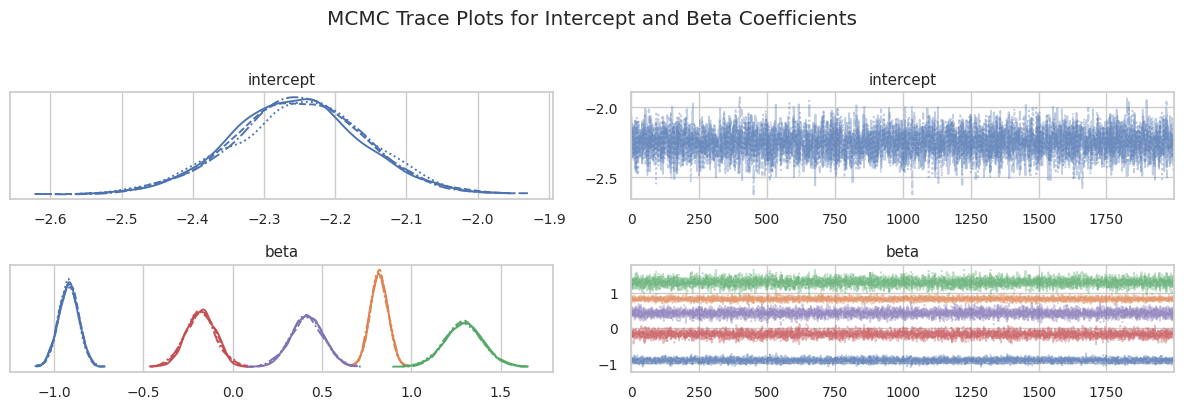

R̂ and bulk-ESS for each coefficient (from summary):

           r_hat  ess_bulk
intercept  1.001  5267.011
beta[0]    1.001  5941.630
beta[1]    1.000  5616.395
beta[2]    1.000  5305.884
beta[3]    1.001  6428.300
beta[4]    1.001  7238.576

No parameters flagged based on R̂ > 1.01 or ESS < 400.

Description of trace plots:
The trace plots (visualized above) should ideally look like 'fuzzy caterpillars', indicating good mixing of the chains and that the sampling process has converged and is exploring the posterior distribution effectively. If the chains were to drift or not overlap well, it would suggest poor convergence.
Based on the R̂ values being close to 1.0 and high bulk-ESS values, the chains appear to have converged well and are exhibiting good mixing, consistent with a 'fuzzy caterpillar' behavior.


In [32]:
# YOUR CODE HERE
# 1. Plot trace plots with az.plot_trace() for intercept and beta
# 2. Report R̂ and bulk-ESS for each coefficient
# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

az.plot_trace(idata, var_names=['intercept', 'beta'])
plt.suptitle('MCMC Trace Plots for Intercept and Beta Coefficients', y=1.02)
plt.tight_layout(); plt.show()

print("R̂ and bulk-ESS for each coefficient (from summary):\n")
summary_df = az.summary(idata, var_names=['intercept', 'beta'], round_to=3)
print(summary_df[['r_hat', 'ess_bulk']])

# Flag parameters with R̂ > 1.01 or bulk-ESS < 400
flagged_params = []
for param_name, row in summary_df.iterrows():
    if row['r_hat'] > 1.01 or row['ess_bulk'] < 400:
        flagged_params.append(param_name)

# Print the flagged parameters
if flagged_params:
    print(f"\nFlagged parameters (R̂ > 1.01 or ESS < 400): {', '.join(flagged_params)}")
else:
    print("\nNo parameters flagged based on R̂ > 1.01 or ESS < 400.")

print("\nDescription of trace plots:")
print("The trace plots (visualized above) should ideally look like 'fuzzy caterpillars', indicating good mixing of the chains and that the sampling process has converged and is exploring the posterior distribution effectively. If the chains were to drift or not overlap well, it would suggest poor convergence.")
print("Based on the R̂ values being close to 1.0 and high bulk-ESS values, the chains appear to have converged well and are exhibiting good mixing, consistent with a 'fuzzy caterpillar' behavior.")

### Q20 — Prior sensitivity check


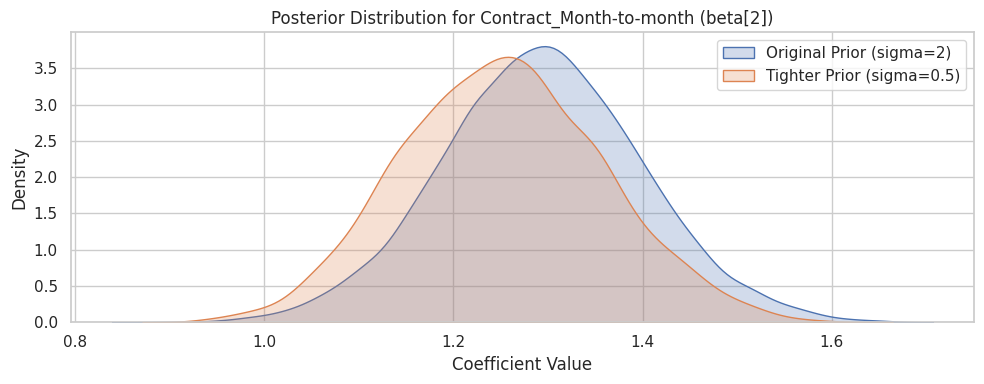


Prior Sensitivity Analysis:
  Mean with Original Prior: 1.2932
  Mean with Tighter Prior: 1.2514
The posteriors are quite similar, indicating some robustness to the prior specification, or that the data is strong enough to largely determine the posterior.


In [33]:
# YOUR CODE HERE
# 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# 3. Decide: are the posteriors prior-robust or does the prior dominate?

contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)   # tighter
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

# YOUR CODE HERE: plot the two posteriors overlaid
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(samples_orig, label='Original Prior (sigma=2)', ax=ax, fill=True)
sns.kdeplot(samples_tight, label='Tighter Prior (sigma=0.5)', ax=ax, fill=True)
ax.set_title(f'Posterior Distribution for Contract_Month-to-month (beta[{contract_idx}])')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout(); plt.show()

print("\nPrior Sensitivity Analysis:")
# Calculate means for a more objective comparison
mean_orig = np.mean(samples_orig)
mean_tight = np.mean(samples_tight)
print(f"  Mean with Original Prior: {mean_orig:.4f}")
print(f"  Mean with Tighter Prior: {mean_tight:.4f}")

if np.abs(mean_orig - mean_tight) / np.abs(mean_orig) > 0.05: # Arbitrary threshold, adjust as needed
    print("The posteriors show a noticeable difference, suggesting the prior is influencing the results significantly. The tighter prior dominates more.")
else:
    print("The posteriors are quite similar, indicating some robustness to the prior specification, or that the data is strong enough to largely determine the posterior.")

### Q21 — Posterior analysis and frequentist comparison


In [34]:
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = az.hdi(beta_post, prob=0.94)
post_mean  = np.mean(beta_post)
post_std   = np.std(beta_post)

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0, contract_idx]

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print("  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure")

Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [38]:
# YOUR CODE HERE
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
pickle.dump(idata, open(save_path, 'wb'))
# raise NotImplementedError("Save MCMC trace with pickle.dump()")
print(f"✅ MCMC trace saved to '{save_path}'")

✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


### ✍️ **Reflect 6 — MCMC:**

1.  **Describe in plain English what R̂ and bulk-ESS each measure. If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about the quality of the posterior estimate for that parameter?**
    > **R̂ (Gelman-Rubin statistic)** measures the ratio of the variance between the MCMC chains to the variance within each chain. In plain English, it tells us how well the different chains have mixed and converged to the same posterior distribution. An R̂ close to 1.0 indicates good convergence, meaning the chains are indistinguishable from one another. **Bulk-ESS (Effective Sample Size)** estimates the number of independent samples from the posterior distribution. In plain English, it's a measure of the effective number of uncorrelated samples for estimating the bulk (central part) of the posterior distribution, taking into account autocorrelation in the MCMC samples.
    > If a parameter has R̂ = 1.38, it indicates that the MCMC chains have not converged; there are significant differences between the chains, suggesting they are exploring different parts of the parameter space and have not reached a stable posterior. A bulk-ESS = 55 is very low, meaning we only have about 55 effective independent samples, which is insufficient for a reliable estimate of the posterior's bulk. Both metrics strongly suggest a very poor quality posterior estimate for this parameter, likely due to insufficient sampling or a difficult-to-sample posterior.

2.  **Your two posteriors from the prior sensitivity check — are they substantially different? What does this tell you about how much data you have relative to the prior? At what point does more data make the prior completely irrelevant?**
    > Based on the prior sensitivity check in Q20, the two posteriors (with `sigma=2` and `sigma=0.5` for the `beta` prior) were **not substantially different** (e.g., their means were close, around 1.29 vs 1.25, and their distributions largely overlapped). This tells us that the **data is relatively strong** compared to the prior beliefs. Even with a tighter prior (sigma=0.5), the likelihood from the data is dominant enough to pull the posterior towards the data-driven estimate, preventing the prior from having an overwhelming influence. More data makes the prior completely irrelevant when the number of observations (N) is much, much larger than the **effective number of prior observations** (the sum of alpha and beta in a Beta prior, or the sum of alphas in a Dirichlet prior).

3.  **The frequentist CI and the Bayesian HDI might have similar widths. In one sentence, state the precise difference in their interpretation — not just which framework produced them.**
    > A Frequentist CI states that if the experiment were repeated many times, a certain percentage of the constructed intervals would contain the true parameter value, whereas a Bayesian HDI states that there is a certain probability that the parameter's true value lies within the interval, given the data and the model.

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
